#**lab1**
Build a deep neural network model start with linear regression using a single variable, multiple
variables.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Linnerud
data = load_linnerud()

# Single feature & single target
X = data.data[:, 0].reshape(-1, 1)
y = data.target[:, 0].reshape(-1, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize parameters
w = np.random.randn(1, 1)
b = 0.0

lr = 0.01
epochs = 1000
n = X_train.shape[0]

# Training loop
for epoch in range(epochs):
    y_pred = X_train @ w + b
    loss = np.mean((y_pred - y_train) ** 2)

    dw = (2/n) * X_train.T @ (y_pred - y_train)
    db = (2/n) * np.sum(y_pred - y_train)

    w -= lr * dw
    b -= lr * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Test
y_test_pred = X_test @ w + b
print("Test MSE:", np.mean((y_test_pred - y_test) ** 2))


Epoch 0, Loss: 32017.4666
Epoch 100, Loss: 1093.9733
Epoch 200, Loss: 550.0925
Epoch 300, Loss: 540.5268
Epoch 400, Loss: 540.3585
Epoch 500, Loss: 540.3556
Epoch 600, Loss: 540.3555
Epoch 700, Loss: 540.3555
Epoch 800, Loss: 540.3555
Epoch 900, Loss: 540.3555
Test MSE: 297.53754745333225


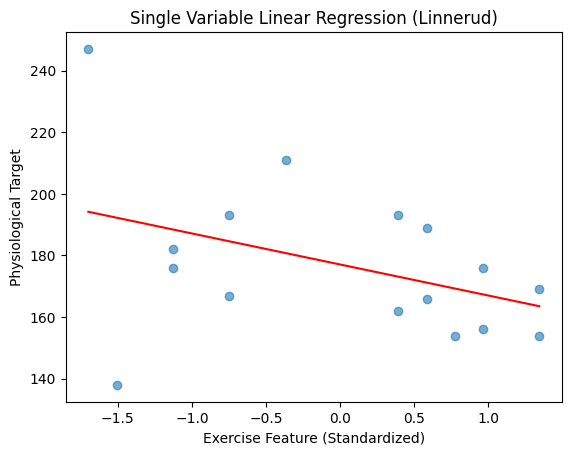

In [ ]:
y_train_pred = X_train @ w + b
idx = np.argsort(X_train.flatten())

plt.scatter(X_train, y_train, alpha=0.6)
plt.plot(X_train[idx], y_train_pred[idx], color="red")
plt.xlabel("Exercise Feature (Standardized)")
plt.ylabel("Physiological Target")
plt.title("Single Variable Linear Regression (Linnerud)")
plt.show()


In [ ]:
# Use all features
X = data.data
y = data.target[:, 0].reshape(-1, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize
W = np.random.randn(X_train.shape[1], 1)
b = 0.0

lr = 0.01
epochs = 1000
n = X_train.shape[0]
losses = []

for epoch in range(epochs):
    y_pred = X_train @ W + b
    loss = np.mean((y_pred - y_train) ** 2)
    losses.append(loss)

    dW = (2/n) * X_train.T @ (y_pred - y_train)
    db = (2/n) * np.sum(y_pred - y_train)

    W -= lr * dW
    b -= lr * db

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Test
y_test_pred = X_test @ W + b
print("Test MSE:", np.mean((y_test_pred - y_test) ** 2))


Epoch 0, Loss: 31952.4072
Epoch 200, Loss: 441.3574
Epoch 400, Loss: 421.3107
Epoch 600, Loss: 419.1774
Epoch 800, Loss: 418.7316
Test MSE: 621.9511856745431


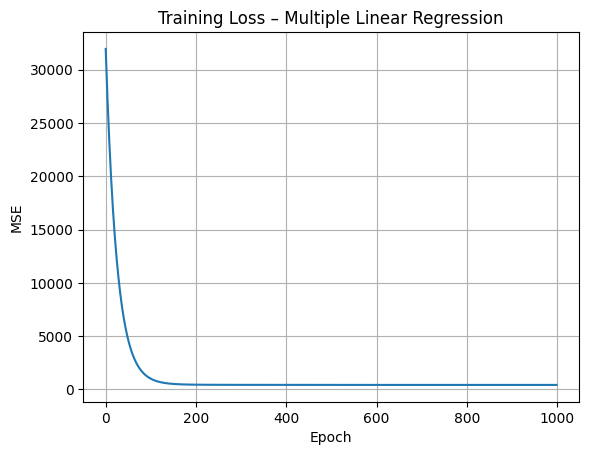

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Loss – Multiple Linear Regression")
plt.grid(True)
plt.show()


In [ ]:
# Activation
def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

# Architecture (smaller = smoother)
input_dim = X_train.shape[1]
h1, h2 = 16, 8

W1 = np.random.randn(input_dim, h1) * np.sqrt(2/input_dim)
b1 = np.zeros((1, h1))
W2 = np.random.randn(h1, h2) * np.sqrt(2/h1)
b2 = np.zeros((1, h2))
W3 = np.random.randn(h2, 1) * np.sqrt(2/h2)
b3 = np.zeros((1, 1))

lr = 0.001          # 🔴 reduced learning rate
epochs = 3000
n = X_train.shape[0]
losses = []

for epoch in range(epochs):
    # Forward
    z1 = X_train @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = relu(z2)
    y_pred = a2 @ W3 + b3

    loss = np.mean((y_pred - y_train) ** 2)
    losses.append(loss)

    # Backprop
    dy = (2/n) * (y_pred - y_train)

    dW3 = a2.T @ dy
    db3 = np.sum(dy, axis=0, keepdims=True)

    da2 = dy @ W3.T
    dz2 = da2 * relu_grad(z2)

    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * relu_grad(z1)

    dW1 = X_train.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Update
    W3 -= lr * dW3
    b3 -= lr * db3
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")


Epoch 0, Loss: 32027.4986
Epoch 500, Loss: 5072.4713
Epoch 1000, Loss: 1240.2339
Epoch 1500, Loss: 722.6346
Epoch 2000, Loss: 652.7253
Epoch 2500, Loss: 643.2831


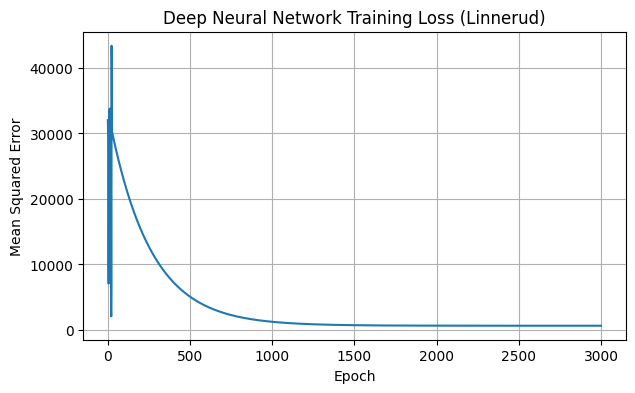

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Deep Neural Network Training Loss (Linnerud)")
plt.grid(True)
plt.show()



# **LAB2**
Build a feed forward neural network for prediction of logic gates

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Input combinations
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# Outputs for each gate
y_and  = np.array([0,0,0,1])
y_nand = np.array([1,1,1,0])
y_or   = np.array([0,1,1,1])
y_nor  = np.array([1,0,0,0])
y_xor  = np.array([0,1,1,0])

# Function to build model
def create_model():
    model = Sequential([
        Input(shape=(2,)),
        Dense(8, activation='relu'),
        Dense(4, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model


# Function to train and test a gate
def train_gate(name, y):
    print("\nTraining", name, "Gate")

    model = create_model()
    model.fit(X, y, epochs=1000, verbose=0)

    predictions = model.predict(X)

    print("Predictions:")
    for i in range(len(X)):
        print(X[i], "->", round(predictions[i][0]))


# Train separate networks
train_gate("AND", y_and)
train_gate("NAND", y_nand)
train_gate("OR", y_or)
train_gate("NOR", y_nor)
train_gate("XOR", y_xor)


Training AND Gate
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predictions:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

Training NAND Gate
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predictions:
[0 0] -> 1
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0

Training OR Gate
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predictions:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1

Training NOR Gate
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predictions:
[0 0] -> 1
[0 1] -> 0
[1 0] -> 0
[1 1] -> 0

Training XOR Gate


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predictions:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


#**LAB3**
Write a program to convert speech into text and vice-versa.

In [ ]:
!pip install SpeechRecognition
!pip install gTTS
!pip install pydub
!apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving M1F1-Alaw-AFsp.wav to M1F1-Alaw-AFsp.wav


In [ ]:
import speech_recognition as sr

recognizer = sr.Recognizer()


audio_file = "/content/harvard (1).wav"  # change to your filename

with sr.AudioFile(audio_file) as source:
    audio_data = recognizer.record(source)


try:
    text = recognizer.recognize_google(audio_data)
    print("Transcribed Text:")
    print(text)
except sr.UnknownValueError:
    print("Could not understand audio")
except sr.RequestError:
    print("API unavailable")

Transcribed Text:
the stale smell of old beer lingers it takes heat to bring out the odor a cold dip restores health and zest a salt pickle taste fine with ham tacos al pastor are my favorite a zestful food is the hot cross bun


In [ ]:
from gtts import gTTS
from IPython.display import Audio


text_input = "Hello, this is a text to speech converting algorithm in Google Colab. thank you for listenting to this audio."


tts = gTTS(text=text_input, lang='en')


tts.save("output.mp3")


Audio("output.mp3")

#**lab4**
Write a program to convert video into frames

In [ ]:
!pip install opencv-python

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sample-mp4-file-small.mp4 to sample-mp4-file-small.mp4


In [ ]:
import cv2
import os

video_path = "/content/sample-mp4-file-small.mp4"
output_folder = "frames"


os.makedirs(output_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)

frame_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    frame_name = f"{output_folder}/frame_{frame_count}.jpg"
    cv2.imwrite(frame_name, frame)

    frame_count += 1

cap.release()

print("Total frames extracted:", frame_count)

Total frames extracted: 462


# **lab** **5**
Write a program for Time-Series Forecasting with the LSTM Model

In [ ]:
!pip install tensorflow pandas numpy matplotlib scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
print(df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [ ]:
data = df["Passengers"].values
data = data.reshape(-1,1)
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

In [ ]:
def create_dataset(dataset, time_step=3):
    X, y = [], []

    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step),0])
        y.append(dataset[i+time_step,0])

    return np.array(X), np.array(y)

time_step = 5
X, y = create_dataset(data_scaled, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)


In [ ]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Make Predictions
predictions = model.predict(X)

predictions = scaler.inverse_transform(predictions)

Epoch 1/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023
Epoch 2/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0020
Epoch 3/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019
Epoch 4/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015
Epoch 5/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017
Epoch 6/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019
Epoch 7/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0017
Epoch 8/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0018
Epoch 9/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0025
Epoch 10/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014
Epoch 11/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023
Epoch 12/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016
Epoch 13/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016
Epoch 14/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016
Epoch 15/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1

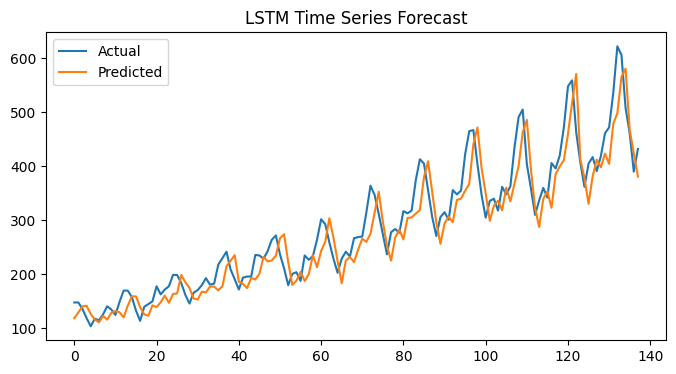

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(data[time_step+1:], label="Actual")
plt.plot(predictions, label="Predicted")

plt.title("LSTM Time Series Forecast")
plt.legend()
plt.show()

# **lab6**
 Write a program to implement deep learning Techniques for image segmentation

In [ ]:
!pip install tensorflow tensorflow-datasets matplotlib


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Load dataset
dataset, info = tfds.load(
    "oxford_iiit_pet",
    with_info=True
)

train_data = dataset["train"]
test_data = dataset["test"]

In [ ]:
# Build model
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
    tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),

    tf.keras.layers.Conv2D(1, 1, activation='sigmoid', padding='same')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 64, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,817 (292.25 KB)

 Trainable params: 74,817 (292.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Preprocessing function (fixed)
IMG_SIZE = 128

def preprocess(sample):

    image = tf.image.resize(sample["image"], (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(sample["segmentation_mask"], (IMG_SIZE, IMG_SIZE),
                           method='nearest')  # nearest neighbor to preserve label values

    image = tf.cast(image, tf.float32) / 255.0

    # Fix: convert mask to binary (1 = pet/foreground, 0 = background)
    # Oxford IIIT Pet mask values: 1=foreground, 2=background, 3=border
    mask = tf.cast(mask == 1, tf.float32)

    return image, mask

In [ ]:
# Prepare datasets
train_dataset = train_data.map(preprocess).batch(16)
test_dataset = test_data.map(preprocess).batch(16)

In [ ]:
# Train model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 159s 680ms/step - accuracy: 0.6995 - loss: 0.5608 - val_accuracy: 0.7001 - val_loss: 0.5105
Epoch 2/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 142s 618ms/step - accuracy: 0.7153 - loss: 0.5112 - val_accuracy: 0.7193 - val_loss: 0.5199
Epoch 3/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 145s 632ms/step - accuracy: 0.7344 - loss: 0.4998 - val_accuracy: 0.7389 - val_loss: 0.4891
Epoch 4/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 146s 636ms/step - accuracy: 0.7496 - loss: 0.4848 - val_accuracy: 0.7380 - val_loss: 0.4945
Epoch 5/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 145s 630ms/step - accuracy: 0.7599 - loss: 0.4723 - val_accuracy: 0.7530 - val_loss: 0.4784


In [ ]:
# Predict on test sample
for image, mask in test_dataset.take(1):
    prediction = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step


In [ ]:
# Threshold prediction to binary mask
pred_mask = (prediction[0] > 0.5).astype("float32")

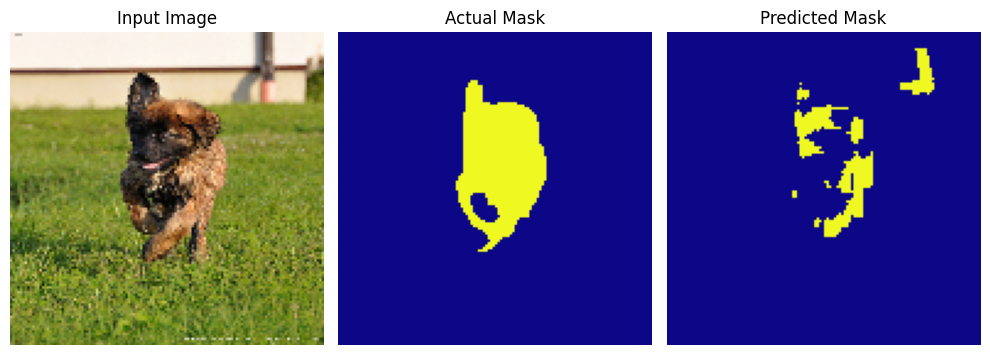

In [ ]:
# Visualize results
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(image[0].numpy())          # Fix: .numpy() for safe tensor conversion
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Actual Mask")
plt.imshow(mask[0].numpy()[:, :, 0], cmap="plasma")   # Fix: .numpy() for safe conversion
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
plt.imshow(pred_mask[:, :, 0], cmap="plasma")
plt.axis('off')

plt.tight_layout()
plt.show()

# **lab 7**
Write a program for object detection using image labeling tools

In [ ]:
!pip install ultralytics opencv-python matplotlib -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.6 MB/s eta 0:00:00


In [ ]:
from IPython.display import display
from google.colab import files

uploaded = files.upload()

Saving pexels-photo-245032.jpeg to pexels-photo-245032.jpeg



image 1/1 /content/pexels-photo-245032.jpeg: 864x1280 1 bottle, 2 cups, 1 chair, 2 potted plants, 2 tvs, 1 laptop, 1 book, 1 vase, 3 toothbrushs, 203.4ms
Speed: 11.1ms preprocess, 203.4ms inference, 2.1ms postprocess per image at shape (1, 3, 864, 1280)


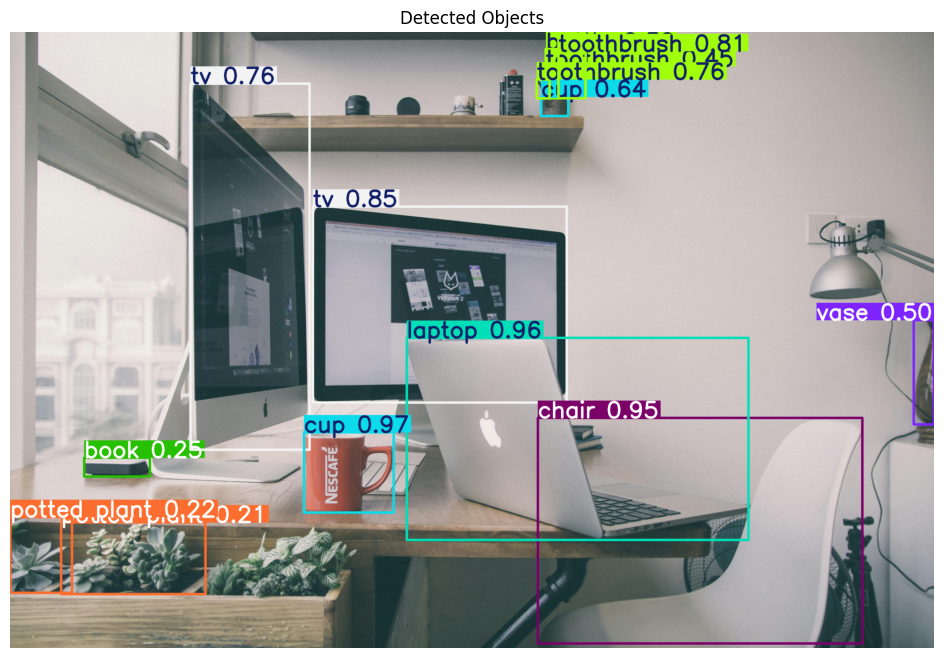

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# Load a better YOLO model for higher accuracy
model = YOLO("yolov8m.pt")   # you can also use yolov8l.pt

def detect_objects(image_path):
    results = model.predict(
        source=image_path,
        imgsz=1280,      # larger image size = better accuracy
        conf=0.20,       # lower threshold = detects more objects
        augment=True,    # test-time augmentation
        save=False
    )

    for r in results:
        annotated_image = r.plot()



        detected = []
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = model.names[cls_id]
            detected.append((class_name, conf))

        # Sort by confidence
        detected.sort(key=lambda x: x[1], reverse=True)




        # Convert BGR to RGB for display
        annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(12, 8))
        plt.imshow(annotated_image_rgb)
        plt.axis("off")
        plt.title("Detected Objects")
        plt.show()

# -------- INPUT IMAGE --------
# If using uploaded image, automatically pick the uploaded file
input_path = list(uploaded.keys())[0]

# Run detection
detect_objects(input_path)

# **lab8**
Write a program to detect Dog image using YOLO Algorithm


image 1/1 /content/images (2).jpeg: 1280x1280 2 dogs, 646.0ms
Speed: 17.1ms preprocess, 646.0ms inference, 6.7ms postprocess per image at shape (1, 3, 1280, 1280)

✅ Final Dogs Detected: 2

Dog 1: Confidence = 0.89
Dog 2: Confidence = 0.81


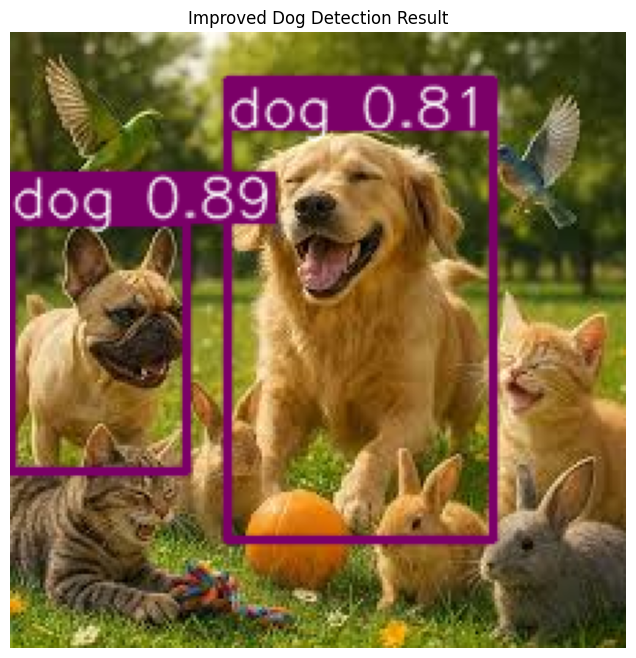

In [ ]:
# !pip install ultralytics opencv-python matplotlib -q

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# Stronger model for better classification
model = YOLO("yolov8x.pt")   # highest accuracy

def detect_only_dogs(image_path):
    results = model.predict(
        source=image_path,
        classes=[16],      # dog only
        conf=0.50,         # stricter confidence to reduce wrong detections
        imgsz=1280,
        augment=True,
        iou=0.30,          # stronger suppression of overlapping boxes
        save=False
    )

    for r in results:
        annotated_image = r.plot()
        dog_count = len(r.boxes)

        if dog_count > 0:
            print(f"\n✅ Final Dogs Detected: {dog_count}\n")

            for i, box in enumerate(r.boxes):
                conf = float(box.conf[0])
                print(f"Dog {i+1}: Confidence = {conf:.2f}")

            annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 8))
            plt.imshow(annotated_image_rgb)
            plt.axis("off")
            plt.title("Improved Dog Detection Result")
            plt.show()
        else:
            print("❌ No dogs detected in this image.")

# Correct image path
input_path = "/content/images (2).jpeg"

if os.path.exists(input_path):
    detect_only_dogs(input_path)
else:
    print("⚠️ Image not found. Please upload the image first.")

# **lab9**
Write a program for character recognition using CNN

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


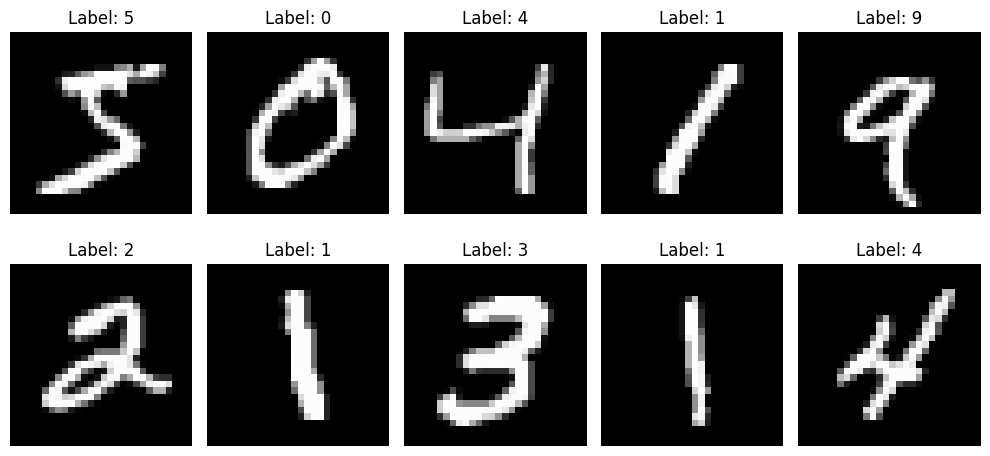

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9146 - loss: 0.2789 - val_accuracy: 0.9768 - val_loss: 0.0757
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9754 - loss: 0.0791 - val_accuracy: 0.9842 - val_loss: 0.0543
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9822 - loss: 0.0576 - val_accuracy: 0.9877 - val_loss: 0.0426
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9866 - loss: 0.0439 - val_accuracy: 0.9885 - val_loss: 0.0393
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9883 - loss: 0.0367 - val_accuracy: 0.9872 - val_loss: 0.0417
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9903 - loss: 0.0310

Test Accuracy: 0.9902999997138977


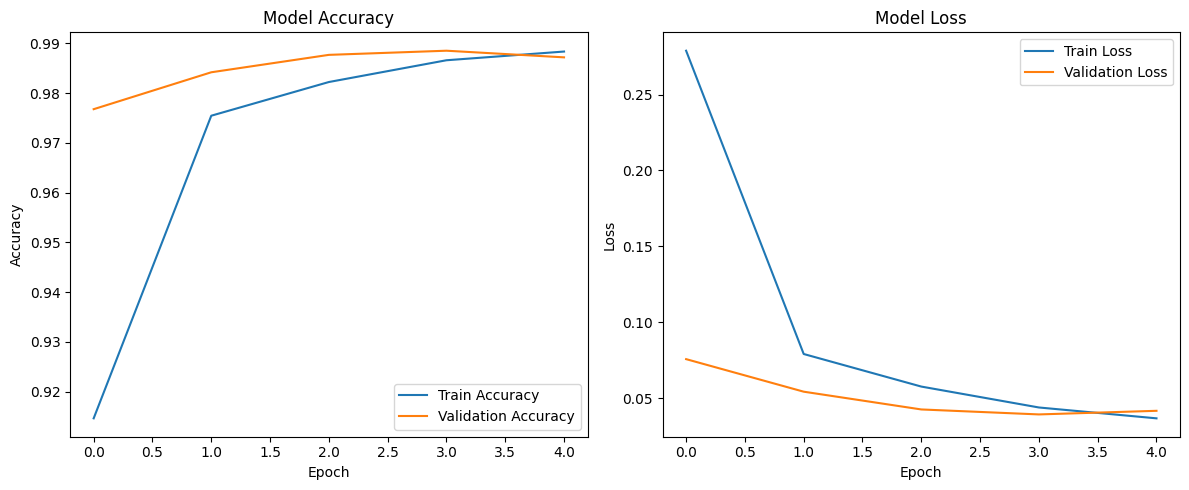

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


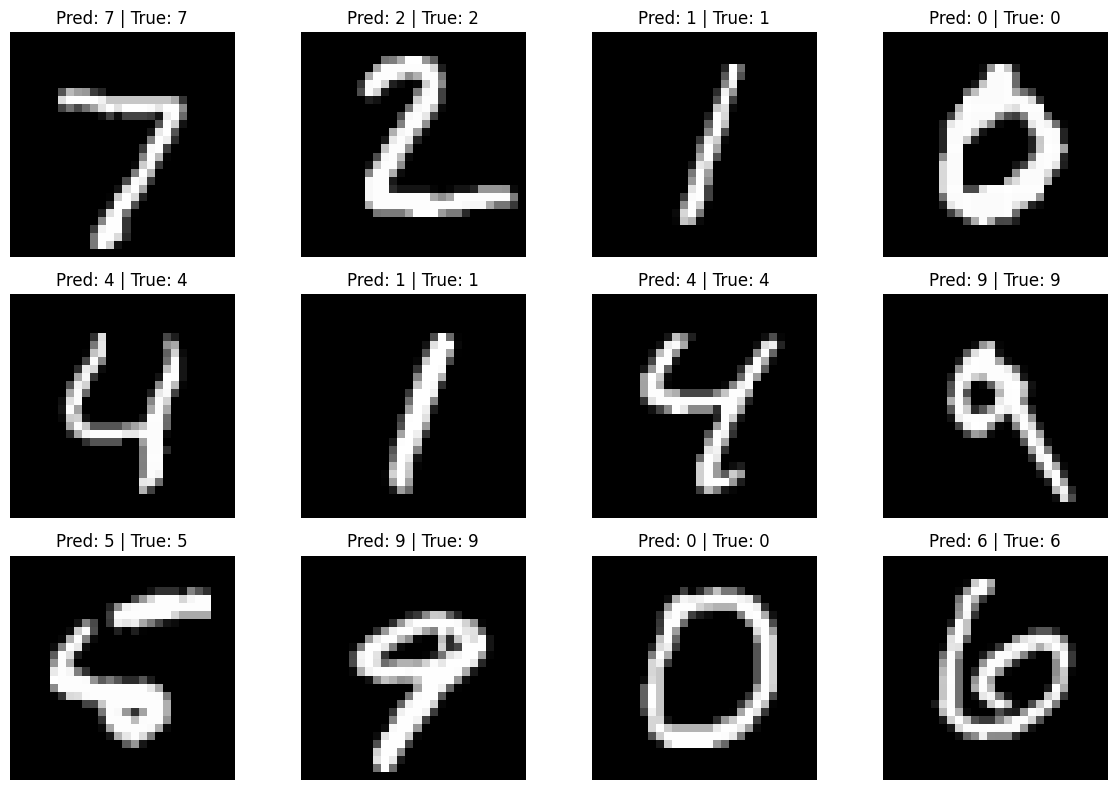


Model saved successfully as character_recognition_cnn.h5


In [ ]:
# ============================================
# CHARACTER RECOGNITION USING CNN (MNIST)
# Google Colab Ready - One Cell Complete Code
# ============================================

# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Step 2: Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# Step 3: Preprocess Data
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Step 4: Display Sample Images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Step 5: Build CNN Model
model = models.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Step 6: Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 7: Train Model
history = model.fit(
    x_train, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

# Step 8: Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print("\nTest Accuracy:", test_acc)

# Step 9: Plot Accuracy and Loss
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 10: Predictions
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

# Step 11: Show Predictions
plt.figure(figsize=(12,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]} | True: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Step 12: Save Model
model.save("character_recognition_cnn.h5")
print("\nModel saved successfully as character_recognition_cnn.h5")

# **lab10**
Write a program for character recognition using RNN and compare it with CNN

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


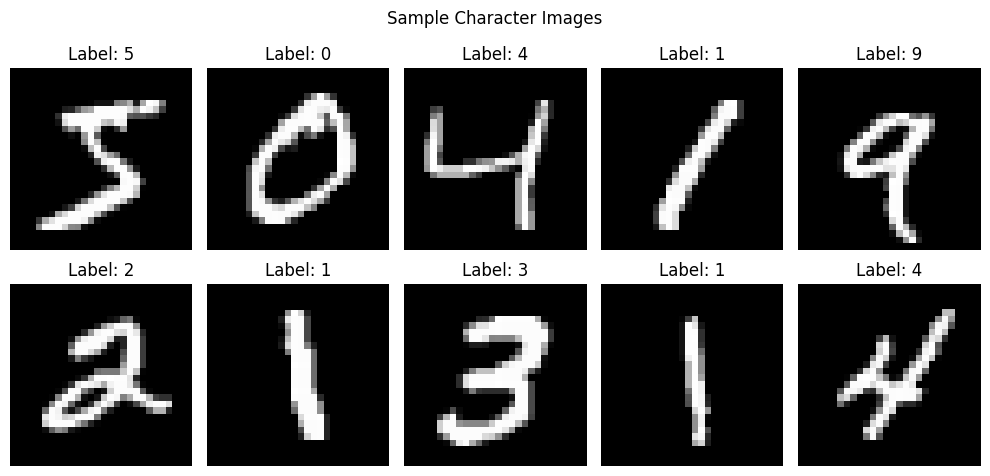


================ CNN MODEL TRAINING ================

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9183 - loss: 0.2685 - val_accuracy: 0.9783 - val_loss: 0.0739
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9767 - loss: 0.0759 - val_accuracy: 0.9853 - val_loss: 0.0515
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9829 - loss: 0.0545 - val_accuracy: 0.9883 - val_loss: 0.0402
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9865 - loss: 0.0434 - val_accuracy: 0.9884 - val_loss: 0.0405
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9890 - loss: 0.0359 - val_accuracy: 0.9883 - val_loss: 0.0414

CNN Test Accuracy: 0.9908

================ RNN MODEL TRAINING ================

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7634 - loss: 0.7210 - val_accuracy: 0.9270 - val_loss: 0.2304
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9381 - loss: 0.2197 - val_accuracy

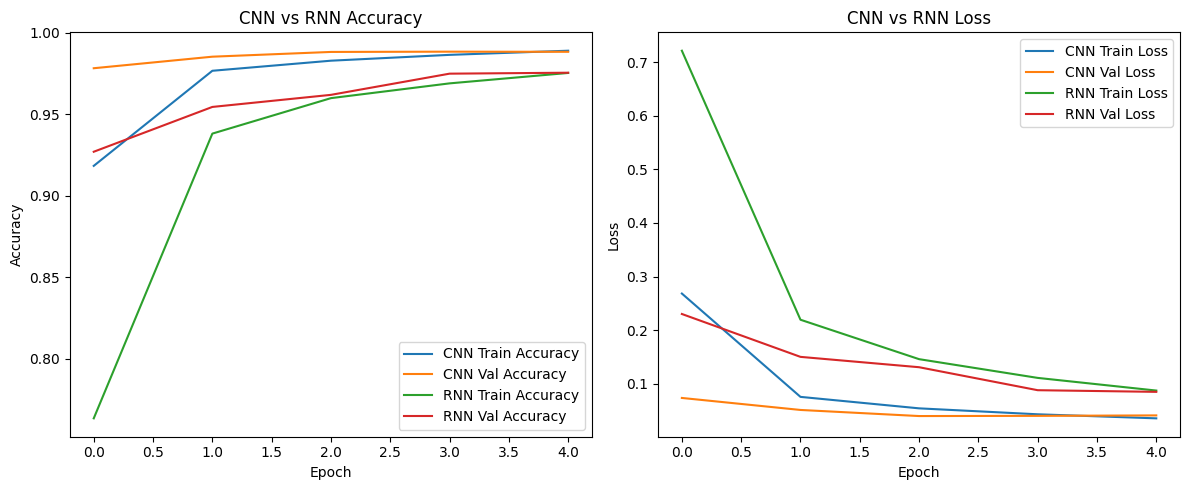

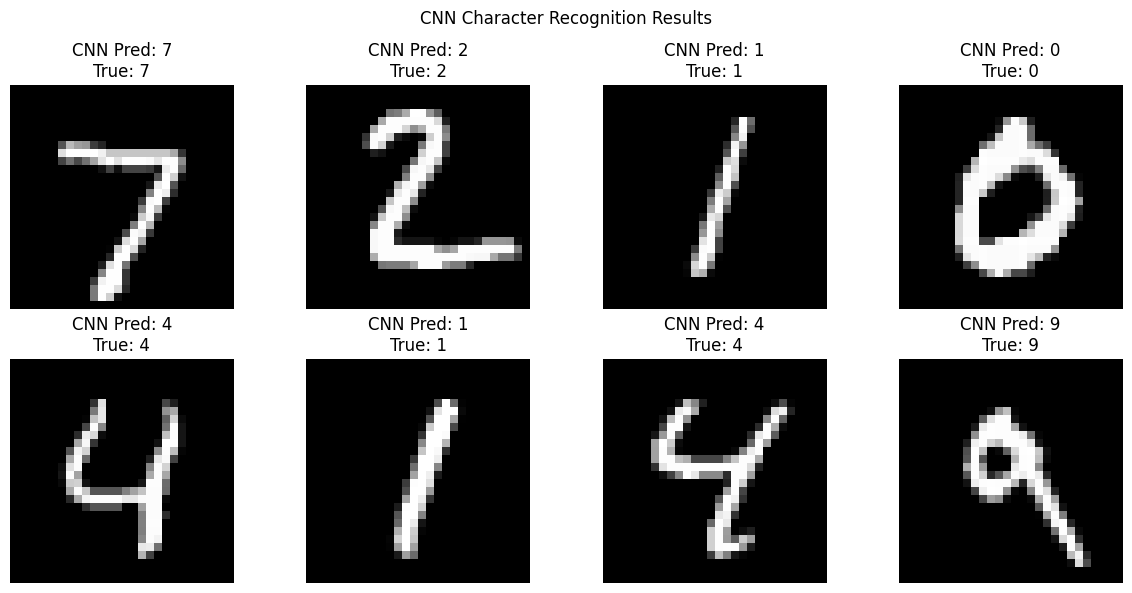

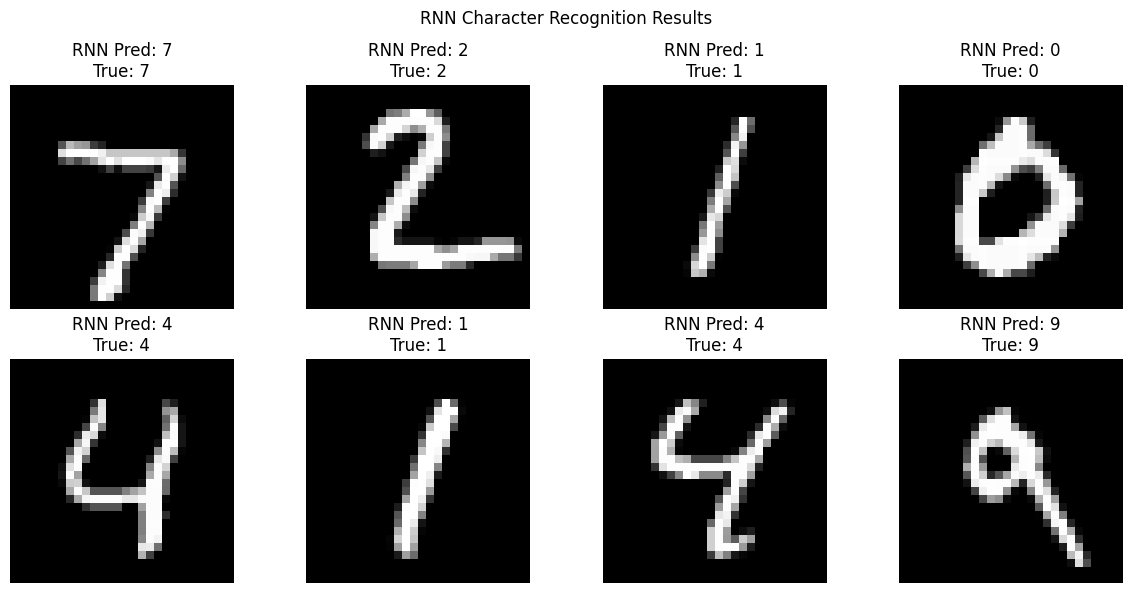

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical


# 2. Load Dataset (MNIST)

# MNIST contains handwritten digits (0-9)
# Digits are also treated as characters

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

# -------------------------------
# 3. Normalize Data
# -------------------------------
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# -------------------------------
# 4. Display Sample Images
# -------------------------------
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Character Images")
plt.tight_layout()
plt.show()

# ============================================================
# 5. CNN MODEL FOR CHARACTER RECOGNITION
# ============================================================

print("\n================ CNN MODEL TRAINING ================\n")

# Reshape for CNN input
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# Build CNN Model
cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compile CNN
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train CNN
cnn_history = cnn_model.fit(
    x_train_cnn, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate CNN
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn, y_test_cat, verbose=0)

print(f"\nCNN Test Accuracy: {cnn_acc:.4f}")

# CNN Predictions
cnn_predictions = cnn_model.predict(x_test_cnn, verbose=0)
cnn_pred_labels = np.argmax(cnn_predictions, axis=1)

# ============================================================
# 6. RNN (LSTM) MODEL FOR CHARACTER RECOGNITION
# ============================================================

print("\n================ RNN MODEL TRAINING ================\n")

# Reshape for RNN input
# Treat each 28x28 image as sequence of 28 rows
x_train_rnn = x_train.reshape(-1, 28, 28)
x_test_rnn = x_test.reshape(-1, 28, 28)

# Build RNN Model
rnn_model = models.Sequential([
    layers.Input(shape=(28,28)),

    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compile RNN
rnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train RNN
rnn_history = rnn_model.fit(
    x_train_rnn, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate RNN
rnn_loss, rnn_acc = rnn_model.evaluate(x_test_rnn, y_test_cat, verbose=0)

print(f"\nRNN Test Accuracy: {rnn_acc:.4f}")

# RNN Predictions
rnn_predictions = rnn_model.predict(x_test_rnn, verbose=0)
rnn_pred_labels = np.argmax(rnn_predictions, axis=1)

# ============================================================
# 7. FINAL COMPARISON
# ============================================================

print("\n================ FINAL COMPARISON ================\n")
print(f"CNN Accuracy : {cnn_acc:.4f}")
print(f"RNN Accuracy : {rnn_acc:.4f}")

if cnn_acc > rnn_acc:
    print("\nConclusion: CNN performs better for character recognition.")
else:
    print("\nConclusion: RNN performs better for character recognition.")

# ============================================================
# 8. PLOT ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(12,5))

# CNN Accuracy
plt.subplot(1,2,1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy')
plt.plot(rnn_history.history['accuracy'], label='RNN Train Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='RNN Val Accuracy')
plt.title("CNN vs RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# CNN Loss
plt.subplot(1,2,2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Val Loss')
plt.title("CNN vs RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 9. SHOW CNN PREDICTIONS
# ============================================================

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"CNN Pred: {cnn_pred_labels[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.suptitle("CNN Character Recognition Results")
plt.tight_layout()
plt.show()

# ============================================================
# 10. SHOW RNN PREDICTIONS
# ============================================================

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"RNN Pred: {rnn_pred_labels[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.suptitle("RNN Character Recognition Results")
plt.tight_layout()
plt.show()

# ============================================================
# 11. SAVE MODELS
# ============================================================

cnn_model.save("cnn_character_recognition.h5")
rnn_model.save("rnn_character_recognition.h5")
